<a href="https://colab.research.google.com/github/sudulran/IT3051-Group27-Hotel-Cancellation-Prediction/blob/main/notebooks/01_Data_Understanding_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Cancellation Prediction

## Notebook 01 — Data Understanding and Exploratory Data Analysis

**Module:** IT3051 – Fundamentals of Data Mining  
**Group:** Group 27 – Entropy Zero

### Machine Learning Task

Binary Classification

### Target Variable

`is_canceled`

- `0` — Not Cancelled
- `1` — Cancelled

### Notebook Objective

This notebook investigates the structure, quality, distributions, relationships,
and potential data leakage issues in the Hotel Booking Demand dataset before
data preprocessing and model development.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
df = pd.read_csv('/content/hotel_bookings(1).csv')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/hotel_bookings(1).csv'

In [ ]:
import os

os.listdir('/content')

['.config', 'hotel_bookings.csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv('/content/hotel_bookings.csv')

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.shape

(119390, 32)

In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Target Variable Analysis

In [ ]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,75166
1,44224


Graph

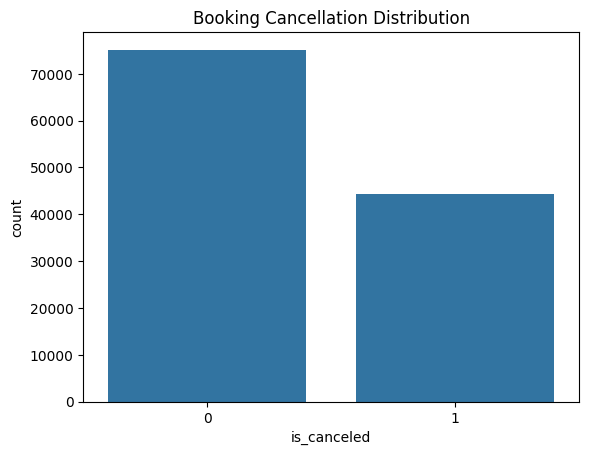

In [ ]:
sns.countplot(
    x='is_canceled',
    data=df
)

plt.title("Booking Cancellation Distribution")
plt.show()

Missing Value Analysis

In [ ]:
missing = df.isnull().sum()

missing[missing>0]

,0
children,4
country,488
agent,16340
company,112593


Percentage

In [ ]:
missing_percentage = (
    df.isnull().sum()/len(df)*100
)

missing_percentage[missing_percentage>0]

,0
children,0.003350
country,0.408744
agent,13.686238
company,94.306893


Handle Missing Values

Children-missing value replace

In [ ]:
df['children'].fillna(
    0,
    inplace=True
)

/tmp/ipykernel_5621/3702303273.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(


Country-missing values

In [ ]:
df['country'].fillna(
    'Unknown',
    inplace=True
)

/tmp/ipykernel_5621/2491406468.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna(


agent/company

Missing = no agent/company.


In [ ]:
df['agent'].fillna(
    0,
    inplace=True
)


df['company'].fillna(
    0,
    inplace=True
)

/tmp/ipykernel_5621/3759649375.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['agent'].fillna(
/tmp/ipykernel_5621/3759649375.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}

Duplicate Records Check

In [ ]:
df.duplicated().sum()

np.int64(31994)

Remove duplicate values

In [ ]:
df.drop_duplicates(
    inplace=True
)

Invalid Data Check
Adults + Children + Babies

In [ ]:
df[
(df['adults']==0) &
(df['children']==0) &
(df['babies']==0)
].shape

(166, 32)

Remove invalid booking

In [ ]:
df = df[
~(
(df['adults']==0) &
(df['children']==0) &
(df['babies']==0)
)
]

Outlier Detection

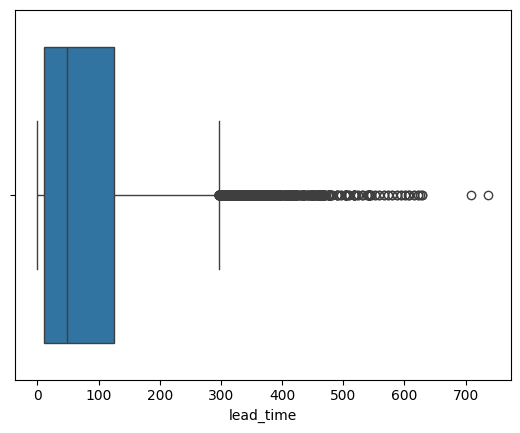

In [ ]:
sns.boxplot(
    x=df['lead_time']
)

plt.show()

# **Feature Engineering**

Total stay nights

In [ ]:
df['total_stay'] = (
    df['stays_in_weekend_nights']
    +
    df['stays_in_week_nights']
)

Total guests

In [ ]:
df['total_guests'] = (
    df['adults']
    +
    df['children']
    +
    df['babies']
)

Remove Data Leakage Columns

In [ ]:
df.drop(
[
'reservation_status',
'reservation_status_date'
],
axis=1,
inplace=True
)

Convert Categorical Data

In [ ]:
df.select_dtypes(
include='object'
).columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object')

In [ ]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col]=encoder.fit_transform(df[col])

Separate X and y

In [ ]:
X = df.drop(
'is_canceled',
axis=1
)

y = df['is_canceled']

Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Save Clean Dataset

In [ ]:
df.to_csv(
'processed_hotel_bookings.csv',
index=False
)